Total images found in dataset: 600

--- Starting Batch Processing Logic (Simulation) ---
Batch 1: Processed 10 images.
Batch 2: Processed 10 images.
Batch 3: Processed 10 images.
Batch 4: Processed 10 images.
Batch 5: Processed 10 images.
Batch 6: Processed 10 images.
Batch 7: Processed 10 images.
Batch 8: Processed 10 images.
Batch 9: Processed 10 images.
Batch 10: Processed 10 images.
Batch 11: Processed 10 images.
Batch 12: Processed 10 images.
Batch 13: Processed 10 images.
Batch 14: Processed 10 images.
Batch 15: Processed 10 images.
Batch 16: Processed 10 images.
Batch 17: Processed 10 images.
Batch 18: Processed 10 images.
Batch 19: Processed 10 images.
Batch 20: Processed 10 images.
Batch 21: Processed 10 images.
Batch 22: Processed 10 images.
Batch 23: Processed 10 images.
Batch 24: Processed 10 images.
Batch 25: Processed 10 images.
Batch 26: Processed 10 images.
Batch 27: Processed 10 images.
Batch 28: Processed 10 images.
Batch 29: Processed 10 images.
Batch 30: Processed 1

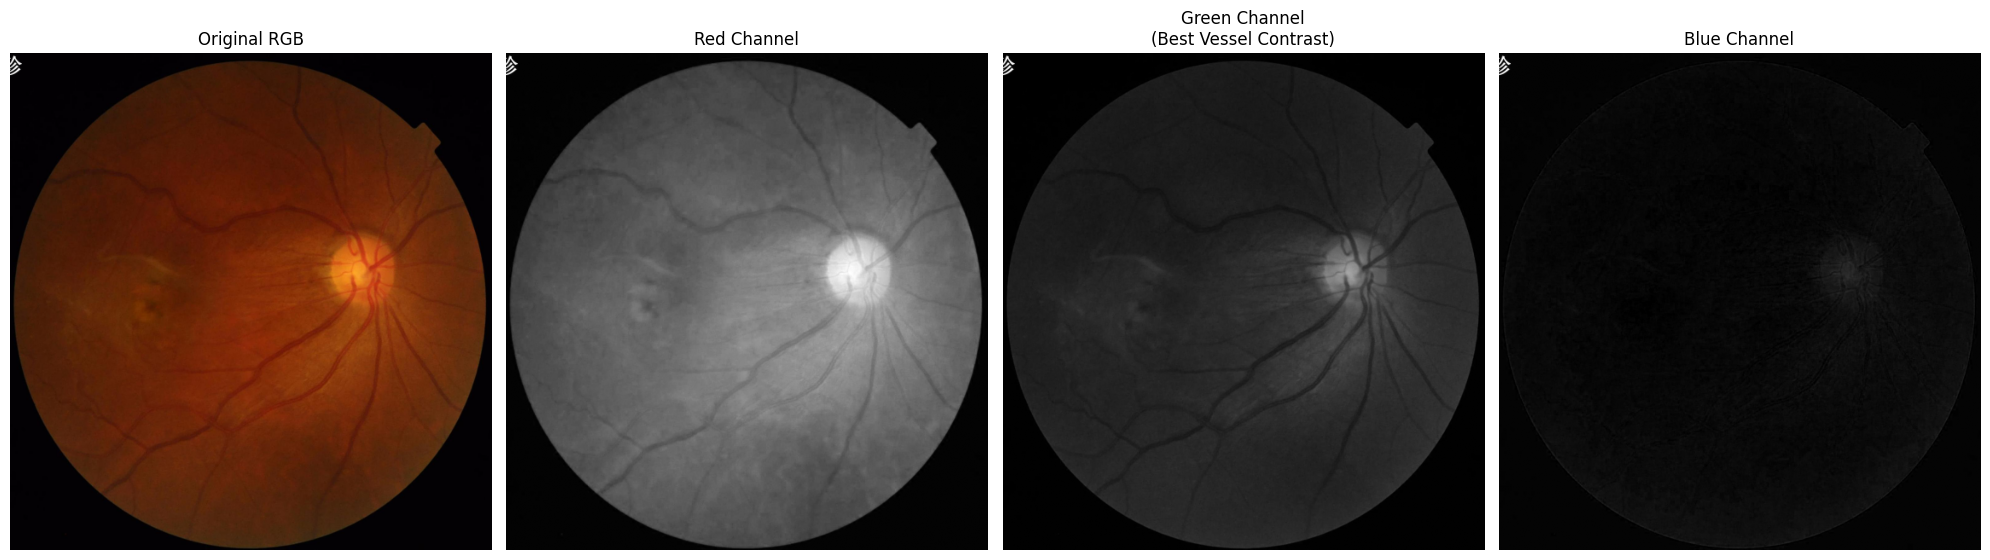

In [6]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import gc

# =====================================================================
# 1. SETUP & PATH LOADING (Memory Efficient)
# =====================================================================

def get_file_paths(folder_path):
    """
    Returns a list of file paths. fast and low memory usage.
    """
    if not os.path.exists(folder_path):
        return []
    valid_exts = ('.png', '.jpg', '.jpeg', '.tif', '.bmp')
    # Use generator expression or list comp just for paths
    return sorted([
        os.path.join(folder_path, f) 
        for f in os.listdir(folder_path) 
        if f.lower().endswith(valid_exts)
    ])

def extract_green_channel(image_rgb):
    """
    Extracts the Green channel from an RGB image.
    """
    return image_rgb[:, :, 1]

def batch_generator(file_paths, batch_size=32):
    """
    Yields batches of images. This allows iterating through 800 images
    without ever holding more than 'batch_size' images in RAM.
    """
    total = len(file_paths)
    for i in range(0, total, batch_size):
        batch_paths = file_paths[i : i + batch_size]
        batch_images = []
        
        for fp in batch_paths:
            img = cv2.imread(fp)
            if img is not None:
                # Convert BGR (OpenCV default) to RGB
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                batch_images.append(img_rgb)
        
        yield batch_images, batch_paths

# =====================================================================
# 2. MAIN EXECUTION
# =====================================================================

base_dir = "dataset"
train_orig_dir = os.path.join(base_dir, "train", "Original")

# 1. Get ALL paths (For 800 images, this is instant and tiny in memory)
all_img_paths = get_file_paths(train_orig_dir)
print(f"Total images found in dataset: {len(all_img_paths)}")

if len(all_img_paths) > 0:

    # -----------------------------------------------------------------
    # OPTIONAL: Process ALL 800 images in batches
    # -----------------------------------------------------------------
    print("\n--- Starting Batch Processing Logic (Simulation) ---")
    
    batch_size = 10
    
    for batch_idx, (batch_imgs, batch_files) in enumerate(batch_generator(all_img_paths, batch_size)):
        green_channels = [extract_green_channel(img) for img in batch_imgs]
        
        # ... Perform processing here ...
        
        print(f"Batch {batch_idx+1}: Processed {len(batch_imgs)} images.")
        
        del batch_imgs, green_channels
        gc.collect() 
        
    print("--- Batch Processing Complete ---\n")

    # -----------------------------------------------------------------
    # 3. SPECIFIC INDEX VISUALIZATION (Index 599)
    # -----------------------------------------------------------------
    target_idx = 599
    
    print(f"Attempting to select image at index {target_idx}...")
    
    # Safety Check: Ensure the dataset actually has enough images
    if target_idx < len(all_img_paths):
        selected_path = all_img_paths[target_idx]
        
        # Load ONLY that image
        img_bgr = cv2.imread(selected_path)
        
        if img_bgr is not None:
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            
            # C. Split Channels
            R = img_rgb[:, :, 0]
            G = extract_green_channel(img_rgb)
            B = img_rgb[:, :, 2]
            
            # D. Plot
            fig, axes = plt.subplots(1, 4, figsize=(20, 6))
            
            # Original
            axes[0].imshow(img_rgb)
            axes[0].set_title(f"Original RGB")
            axes[0].axis('off')
            
            # Red
            axes[1].imshow(R, cmap='gray')
            axes[1].set_title("Red Channel")
            axes[1].axis('off')
            
            # Green
            axes[2].imshow(G, cmap='gray')
            axes[2].set_title("Green Channel\n(Best Vessel Contrast)")
            axes[2].axis('off')
            
            # Blue
            axes[3].imshow(B, cmap='gray')
            axes[3].set_title("Blue Channel")
            axes[3].axis('off')
            
            plt.tight_layout()
            plt.show()
        else:
            print(f"Error: Could not load image at path: {selected_path}")
    else:
        print(f"Error: Index {target_idx} is out of bounds. Dataset has only {len(all_img_paths)} images.")

else:
    print("No images found in directory.")

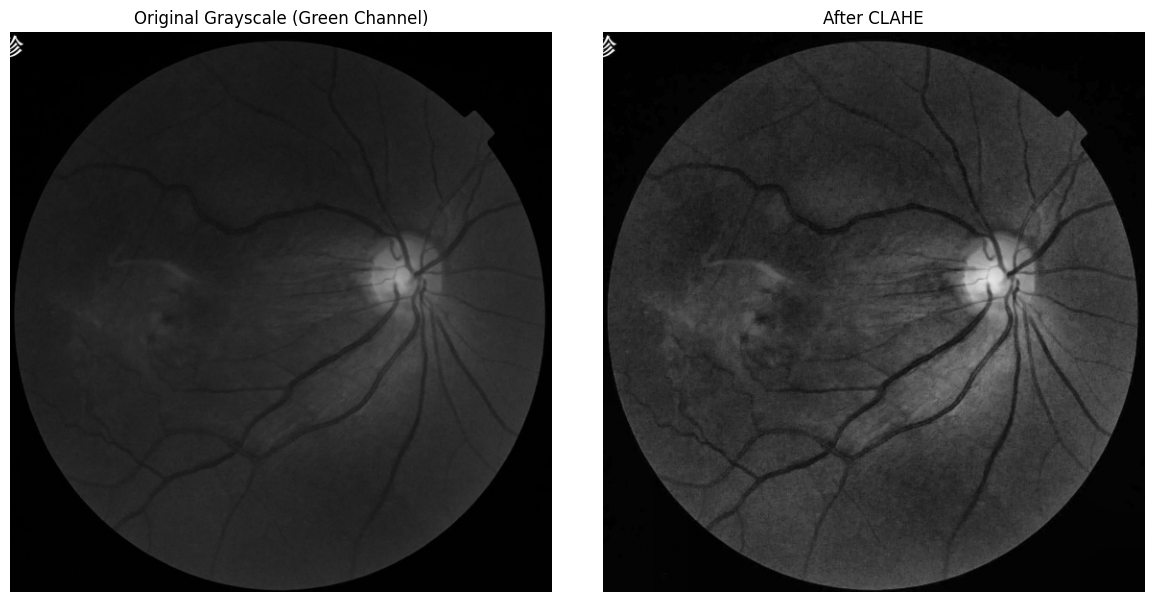

In [8]:
# =====================================================================
# 4. CLAHE FUNCTION DEFINITION
# =====================================================================

def apply_clahe_to_batch(grayscale_images, clip_limit=2.0, tile_size=(8, 8)):
    """
    Applies Contrast Limited Adaptive Histogram Equalization (CLAHE) to a list of images.
    
    Args:
        grayscale_images (list or np.ndarray): List of 2D grayscale images (uint8).
        clip_limit (float): Threshold for contrast limiting. Higher = more contrast.
        tile_size (tuple): Size of grid for region-based equalization.
        
    Returns:
        list: List of CLAHE processed images.
    """
    # Create the CLAHE object
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    
    processed_images = []
    
    # Handle single image input case just in case
    if not isinstance(grayscale_images, list) and len(grayscale_images.shape) == 2:
        return clahe.apply(grayscale_images)

    # Process batch
    for img in grayscale_images:
        # Ensure image is uint8 (required for OpenCV CLAHE)
        if img.dtype != np.uint8:
            img = (img * 255).astype(np.uint8)
            
        enhanced_img = clahe.apply(img)
        processed_images.append(enhanced_img)
        
    return processed_images

# =====================================================================
# 5. EXECUTION & VISUALIZATION (Using Index 599)
# =====================================================================

# We assume 'target_idx', 'all_img_paths', and 'extract_green_channel' 
# are available from the previous code block.

if 'target_idx' in locals() and target_idx < len(all_img_paths):
    
    # 1. Reload Index 599 (Original)
    path_599 = all_img_paths[target_idx]
    img_bgr = cv2.imread(path_599)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # 2. Extract Green Channel (The "Original Grayscale" for this task)
    green_channel = extract_green_channel(img_rgb)
    
    # 3. Apply CLAHE
    # Note: We pass it as a list [green_channel] to fit the batch function signature, 
    # then take the first element [0] back out.
    clahe_output = apply_clahe_to_batch([green_channel], clip_limit=2.0, tile_size=(8,8))[0]
    
    # 4. Plot Comparison
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Original Green Channel
    axes[0].imshow(green_channel, cmap='gray')
    axes[0].set_title(f"Original Grayscale (Green Channel)")
    axes[0].axis('off')
    
    # CLAHE Output
    axes[1].imshow(clahe_output, cmap='gray')
    axes[1].set_title(f"After CLAHE")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

else:
    print("Please run the previous data loading code to define 'target_idx' and 'all_img_paths'.")

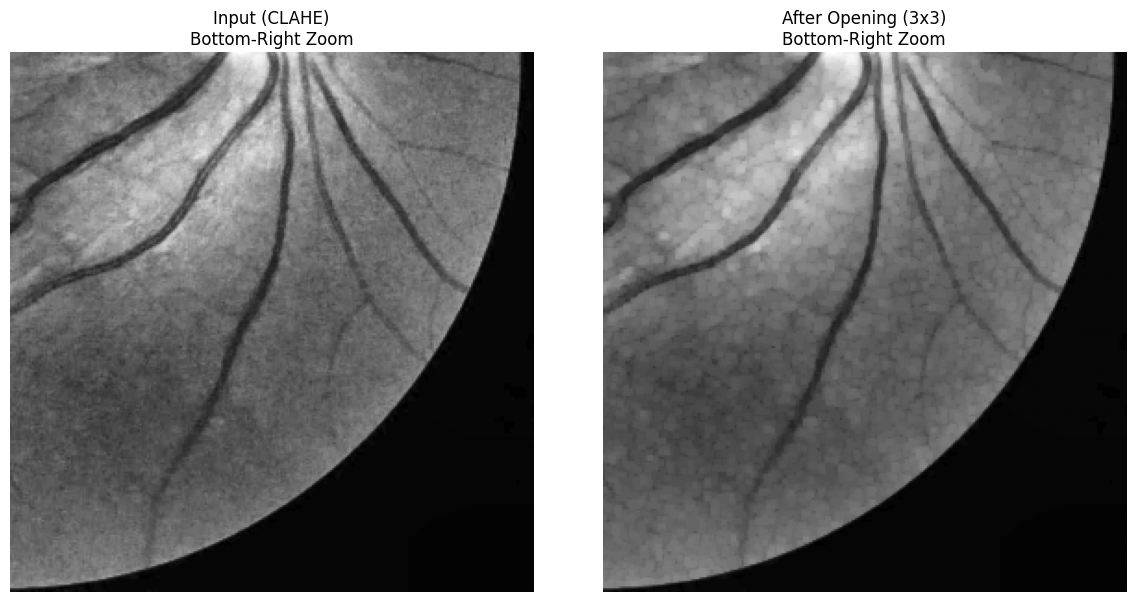

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. DEFINE OPENING FUNCTION (Same as before)
# =====================================================================

def opening(image):
    kernel = np.ones((3, 3), np.uint8)
    opened_image = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
    return opened_image

# =====================================================================
# 2. EXECUTION & ZOOMED VISUALIZATION
# =====================================================================

if 'clahe_output' in locals():
    
    # 1. Apply Opening
    opened_output = opening(clahe_output)
    
    # 2. Calculate Dimensions for Bottom-Right Quadrant
    h, w = clahe_output.shape
    cy, cx = h // 2, w // 2  # Center Y, Center X
    
    # Slice the arrays: [Start_Y : End_Y, Start_X : End_X]
    # Bottom-Right means Y from Center->Bottom, X from Center->Right
    zoom_clahe = clahe_output[cy:h, cx:w]
    zoom_open = opened_output[cy:h, cx:w]
    
    # 3. Plot Comparison (Zoomed)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Input (CLAHE Output) - Zoomed
    axes[0].imshow(zoom_clahe, cmap='gray')
    axes[0].set_title(f"Input (CLAHE)\nBottom-Right Zoom")
    axes[0].axis('off')
    
    # Output (After Opening) - Zoomed
    axes[1].imshow(zoom_open, cmap='gray')
    axes[1].set_title(f"After Opening (3x3)\nBottom-Right Zoom")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

else:
    print("Error: 'clahe_output' variable not found. Please run the CLAHE code block first.")

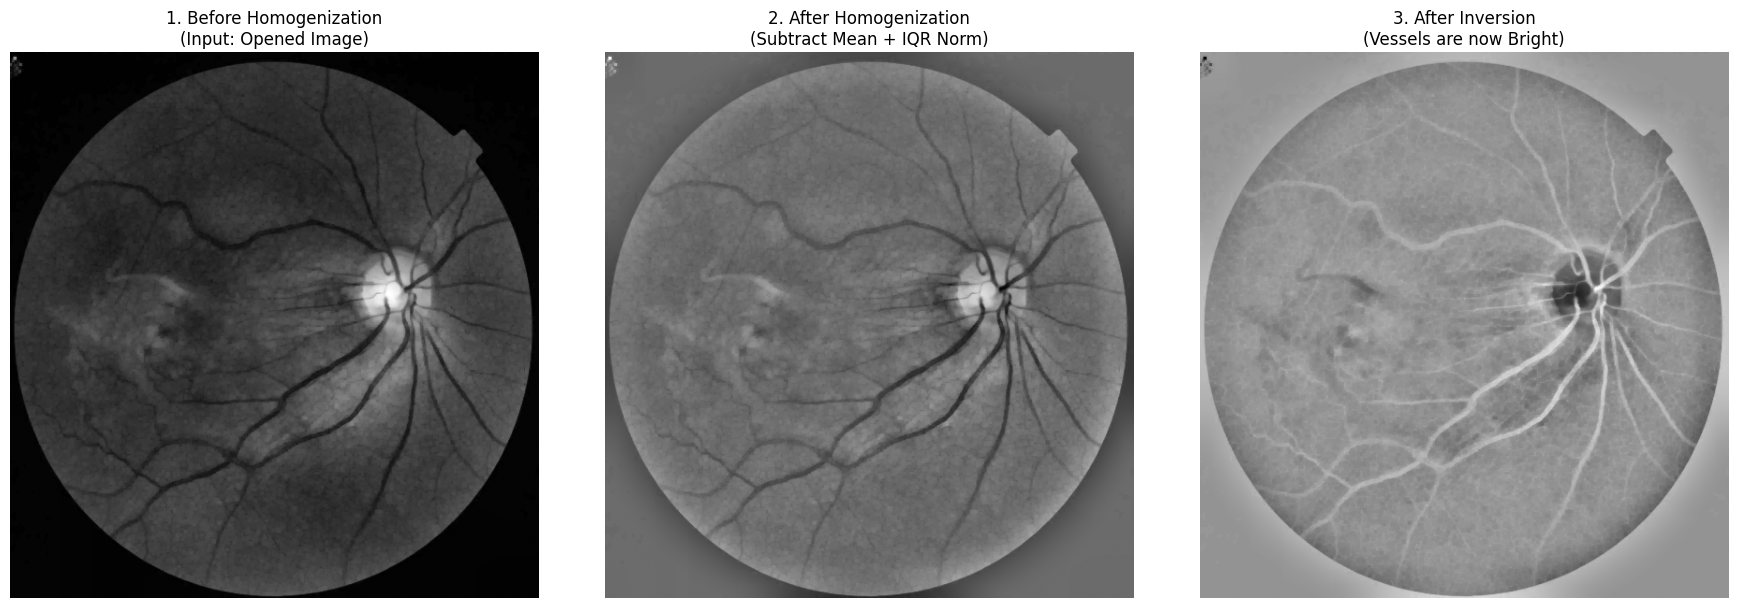

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. DEFINE FUNCTIONS
# =====================================================================

def background_homogenization(image):
    """
    1. Applies 69x69 Mean Filter.
    2. Subtracts filtered image from original (High-pass filter).
    3. Normalizes using Median and IQR (Robust Scaling).
    """
    # Convert to float32 to prevent clipping during subtraction
    img_float = image.astype(np.float32)
    
    # 1. Mean Filter (69x69)
    # This estimates the background luminosity
    mean_bg = cv2.blur(img_float, (69, 69))
    
    # 2. Subtraction (Original - Background)
    # Vessels (Dark) - Background (Bright) = Negative Values
    # Background - Background = ~0
    diff = img_float - mean_bg
    
    # 3. Normalize using Median and IQR
    q75, q25 = np.percentile(diff, [75 ,25])
    iqr = q75 - q25
    median = np.median(diff)
    
    # Avoid division by zero
    if iqr == 0:
        iqr = 1e-6
        
    normalized = (diff - median) / iqr
    
    return normalized

def invert_image(image):
    """
    Inverts the image intensity. 
    For zero-centered normalized data, this is simple negation.
    """
    # Since vessels are negative outliers after homogenization, 
    # multiplying by -1 makes them positive (bright) outliers.
    return -1.0 * image

# =====================================================================
# 2. EXECUTION & VISUALIZATION
# =====================================================================

# We assume 'opened_output' exists from the previous step.

if 'opened_output' in locals():
    
    # 1. Run Background Homogenization
    homogenized_output = background_homogenization(opened_output)
    
    # 2. Run Inversion
    inverted_output = invert_image(homogenized_output)
    
    # 3. Plot Comparison (1x3 Figure)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # A. Input (Opened)
    axes[0].imshow(opened_output, cmap='gray')
    axes[0].set_title("1. Before Homogenization\n(Input: Opened Image)")
    axes[0].axis('off')
    
    # B. After Homogenization
    # Note: Vessels are dark/negative here, background is gray (0)
    axes[1].imshow(homogenized_output, cmap='gray')
    axes[1].set_title("2. After Homogenization\n(Subtract Mean + IQR Norm)")
    axes[1].axis('off')
    
    # C. After Inversion
    # Note: Vessels are now BRIGHT features
    axes[2].imshow(inverted_output, cmap='gray')
    axes[2].set_title("3. After Inversion\n(Vessels are now Bright)")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

else:
    print("Error: 'opened_output' variable not found. Please run the previous code block.")